# Custom CNN — 20 epochs

Training and evaluation of a custom convolutional neural network for binary tuberculosis classification from chest X-ray images.

**Dataset path expected:** `data/TB_Chest_Radiography_Database/`.


Base directory contents: ['.ipynb_checkpoints', 'custom_cnn_tb.h5', 'file.pdf', 'file.png', 'main.py.py', 'Normal', 'Tuberculosis', 'Untitled.ipynb']
Data shape: (7000, 128, 128, 1)
Labels shape: (7000,)
Train data shape: (4900, 128, 128, 1), Train labels shape: (4900,)
Validation data shape: (1050, 128, 128, 1), Validation labels shape: (1050,)
Test data shape: (1050, 128, 128, 1), Test labels shape: (1050,)


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,821,121 (56.54 MB)

 Trainable params: 14,820,737 (56.54 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/20


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


154/154 ━━━━━━━━━━━━━━━━━━━━ 339s 2s/step - accuracy: 0.7922 - loss: 11.8410 - val_accuracy: 0.7619 - val_loss: 8.0570 - learning_rate: 0.0010
Epoch 2/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 335s 2s/step - accuracy: 0.8396 - loss: 7.8608 - val_accuracy: 0.6876 - val_loss: 5.6880 - learning_rate: 0.0010
Epoch 3/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 338s 2s/step - accuracy: 0.8549 - loss: 3.9143 - val_accuracy: 0.8429 - val_loss: 2.3099 - learning_rate: 0.0010
Epoch 4/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 705s 5s/step - accuracy: 0.8515 - loss: 2.0792 - val_accuracy: 0.8543 - val_loss: 1.7022 - learning_rate: 0.0010
Epoch 5/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 272s 2s/step - accuracy: 0.8713 - loss: 1.6782 - val_accuracy: 0.5648 - val_loss: 3.1871 - learning_rate: 0.0010
Epoch 6/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 273s 2s/step - accuracy: 0.8622 - loss: 1.7323 - val_accuracy: 0.9286 - val_loss: 1.0823 - learning_rate: 0.0010
Epoch 7/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 274s 2s/step - accuracy: 0.8857 - loss: 1.0981 - val

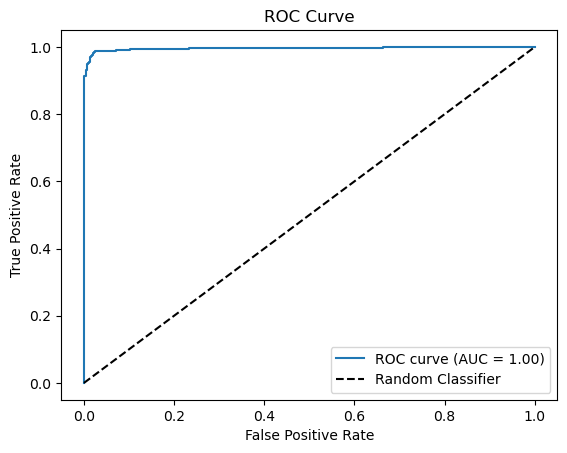

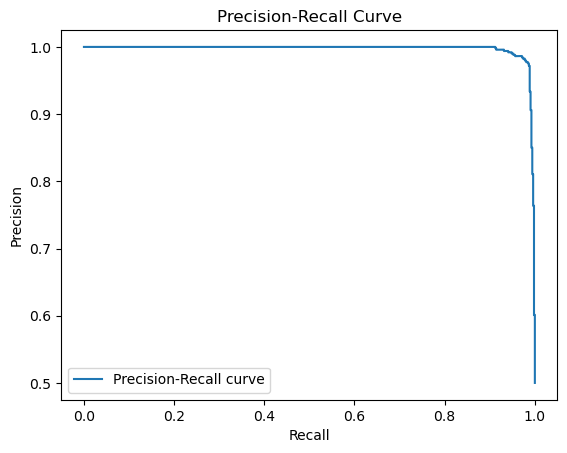

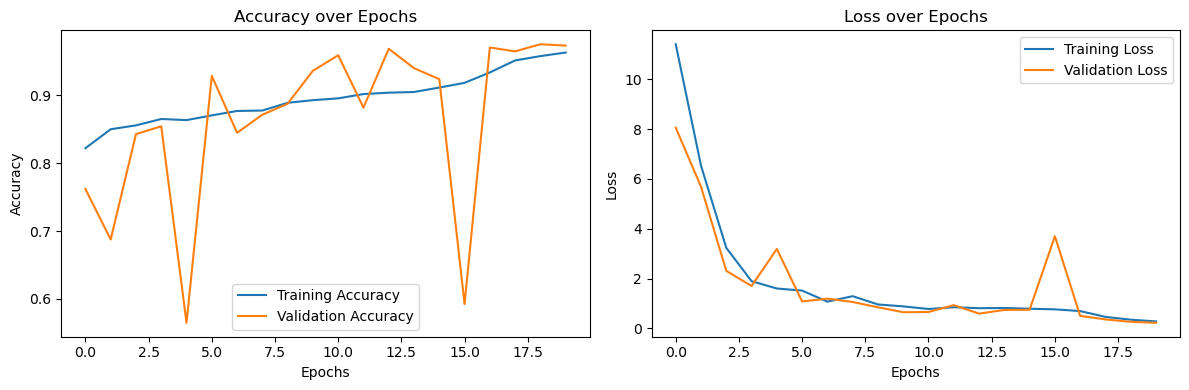

In [ ]:
########20 Epochs CNN Model
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.regularizers import l2

# Step 1: Define base path
base_path = r'data/TB_Chest_Radiography_Database'

# Check base directory contents
print("Base directory contents:", os.listdir(base_path))

# Step 2: Load and preprocess the data
img_size = 128  # Resize images to 128x128

def load_images(base_path, img_size):
    data = []
    labels = []
    categories = ['Normal', 'Tuberculosis']  # Class names
    
    for category in categories:
        path = os.path.join(base_path, category)
        class_label = categories.index(category)  # Assign 0 or 1 as label
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                resized_img = cv2.resize(img_array, (img_size, img_size))
                data.append(resized_img)
                labels.append(class_label)
            except Exception as e:
                print(f"Error loading image: {e}")
    
    return np.array(data), np.array(labels)

# Load data and labels
data, labels = load_images(base_path, img_size)
data = data / 255.0  # Normalize pixel values to [0, 1]

# Reshape data to fit the model input requirements (128, 128, 1)
data = data.reshape(-1, img_size, img_size, 1)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

# Step 3: Split the dataset into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.3, random_state=42, stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train data shape: {X_train.shape}, Train labels shape: {y_train.shape}")
print(f"Validation data shape: {X_val.shape}, Validation labels shape: {y_val.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {y_test.shape}")

# Step 4: Data Augmentation
data_generator = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

data_generator.fit(X_train)

# Step 5: Build the CNN model
model = Sequential([
    Conv2D(64, kernel_size=(3, 3), activation='relu', input_shape=(img_size, img_size, 1)),
    BatchNormalization(),
    MaxPool2D(pool_size=(2, 2)),

    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),

    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Train the model
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, min_lr=0.00001)

history = model.fit(
    data_generator.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr]
)

# Step 7: Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Step 8: Generate predictions
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)

# Step 9: Classification Report and Confusion Matrix
print("Classification Report:\n", classification_report(y_test, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_classes))

# Step 10: ROC and Precision-Recall Curves
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred)

plt.figure()
plt.plot(recall, precision, label="Precision-Recall curve")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()

# Step 11: Training and Validation Accuracy and Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [2]:
# Save the trained model
model.save("tb_cnn_20epochs.h5")
print("Model saved successfully as tb_cnn_20epochs.h5")


Model saved successfully as tb_cnn_20epochs.h5


In [4]:
from tensorflow.keras.models import load_model

# Load your model
model = load_model("tb_cnn_20epochs.h5")